<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/6_Regresi%C3%B3n_Lineal__Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
data= pd.read_csv("Analisis GAC Full7agosto 2026(Marketing).csv")


In [6]:
data.head()

,Marketing,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Leads total,543,178,416,422,967,954,1409,1315,1973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ventas X Mes,12,7,8,13,6,21,17,17,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Desgloce Detallado (Gastos),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
data1 = data.iloc[
    [138, 141, 142, 149, 150, 157, 158],
    0:30
].copy()

data1

,Marketing,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,100%,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
138,Mes,"Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24","Octubre, 24",...,"Septiembre, 25","Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio,26"
141,Leads,0,0,25,28,68,294,248,52,59,...,312,324,274,325,290,433,401,351,352,403
142,Ventas,0,0,0,0,0,2,3,0,2,...,15,12,11,9,6,6,7,8,7,10
149,Leads,57,145,129,463,350,192,1112,1353,1142,...,676,688,554,908,922,635,980,834,667,748
150,Ventas,NaN,1,NaN,NaN,1,2,NaN,6,1,...,15,10,14,8,6,13,11,8,9,7
157,Leads,329,19,76,87,55,92,77,57,43,...,58,72,81,76,97,94,105,79,115,85
158,Ventas,9,4,10,1,3,10,9,6,3,...,7,11,9,9,6,7,8,9,9,11


In [8]:
data1.iloc[:, 0] = [
    'Mes',
    'Leads Plaza',
    'Ventas Plaza',
    'Leads Digitales',
    'Ventas Digitales',
    'Leads Piso',
    'Ventas Piso'
]

data1

,Marketing,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,100%,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
138,Mes,"Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24","Octubre, 24",...,"Septiembre, 25","Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio,26"
141,Leads Plaza,0,0,25,28,68,294,248,52,59,...,312,324,274,325,290,433,401,351,352,403
142,Ventas Plaza,0,0,0,0,0,2,3,0,2,...,15,12,11,9,6,6,7,8,7,10
149,Leads Digitales,57,145,129,463,350,192,1112,1353,1142,...,676,688,554,908,922,635,980,834,667,748
150,Ventas Digitales,NaN,1,NaN,NaN,1,2,NaN,6,1,...,15,10,14,8,6,13,11,8,9,7
157,Leads Piso,329,19,76,87,55,92,77,57,43,...,58,72,81,76,97,94,105,79,115,85
158,Ventas Piso,9,4,10,1,3,10,9,6,3,...,7,11,9,9,6,7,8,9,9,11


In [9]:
data1 = data1.set_index(data1.columns[0]).T
data1 = data1.reset_index(drop=True)

data1

Marketing,Mes,Leads Plaza,Ventas Plaza,Leads Digitales,Ventas Digitales,Leads Piso,Ventas Piso
0,"Febrero, 24",0,0,57,NaN,329,9
1,"Marzo, 24",0,0,145,1,19,4
2,"Abril, 24",25,0,129,NaN,76,10
3,"Mayo, 24",28,0,463,NaN,87,1
4,"Junio, 24",68,0,350,1,55,3
5,"Julio, 24",294,2,192,2,92,10
6,"Agosto, 24",248,3,1112,NaN,77,9
7,"Septiembre, 24",52,0,1353,6,57,6
8,"Octubre, 24",59,2,1142,1,43,3
9,"Noviembre, 24",154,3,846,5,50,11


In [10]:
data1.isnull().sum()

Marketing
Mes                 0
Leads Plaza         0
Ventas Plaza        0
Leads Digitales     0
Ventas Digitales    4
Leads Piso          0
Ventas Piso         0
dtype: int64

In [11]:
columnas_numericas = [
    'Leads Plaza',
    'Ventas Plaza',
    'Leads Digitales',
    'Ventas Digitales',
    'Leads Piso',
    'Ventas Piso'
]

data1[columnas_numericas] = (
    data1[columnas_numericas]
    .fillna(0)
    .apply(pd.to_numeric, errors='coerce')
)

In [12]:
data1.dtypes
data1.isnull().sum()
data1.head()

Marketing,Mes,Leads Plaza,Ventas Plaza,Leads Digitales,Ventas Digitales,Leads Piso,Ventas Piso
0,"Febrero, 24",0,0,57,0,329,9
1,"Marzo, 24",0,0,145,1,19,4
2,"Abril, 24",25,0,129,0,76,10
3,"Mayo, 24",28,0,463,0,87,1
4,"Junio, 24",68,0,350,1,55,3


In [16]:
data1['Ventas Totales'] = (
    data1['Ventas Plaza'] +
    data1['Ventas Digitales'] +
    data1['Ventas Piso']
)

<Axes: xlabel='Leads Plaza', ylabel='Ventas Totales'>

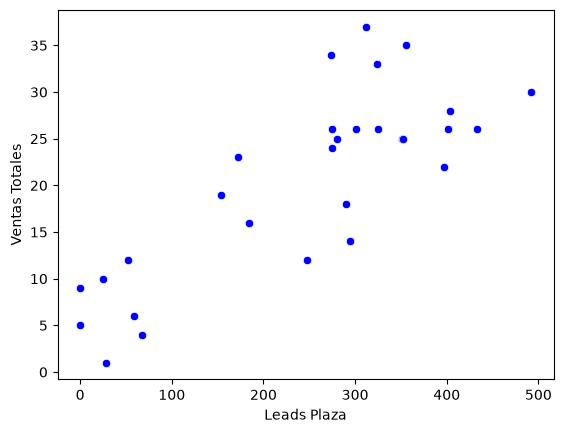

In [17]:
#Imprimimos el scatter plot entre la variable dependiente (total) e independiente (alcohol) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Leads Plaza', y='Ventas Totales', color="blue", data=data1)
#sns.scatterplot(x='speeding', y='total', color="red", data=df)

In [19]:
#Declaramos las variables dependientes e independientes para la regresión lineal
#Vars_Indep= df[['alcohol', 'speeding']]
Vars_Indep= data1[['Leads Plaza', 'Leads Digitales', 'Leads Piso']]
Var_Dep= data1['Ventas Totales']

In [20]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [21]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.06,-0. ,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Leads Plaza','Leads Digitales','Leads Piso']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.464
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [22]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Leads Plaza', 'Leads Digitales', 'Leads Piso'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.05791277, -0.00248352, -0.00673142]),
 'rank_': np.int64(3),
 'singular_': array([1770.41440974,  707.01332132,  262.748369  ]),
 'intercept_': np.float64(8.46422190655519)}

**Modelo matemático: y= 2.0325063(5.640) + 5.857776154826299**

---




In [23]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.6607995377730069

In [25]:
#Predecimos los valores de total de accidentes a partir de la variable "alcohol"
#y_pred= model.predict(X=df[['alcohol', 'speeding']])
y_pred= model.predict(X=data1[['Leads Plaza', 'Leads Digitales', 'Leads Piso']])
y_pred

array([ 6.10802504,  7.97621394,  9.08007893,  8.35027449, 11.16282901,
       24.39445021, 19.54659135,  7.73178673,  8.75543964, 14.94515643,
       22.37392675, 17.44561638, 18.17527195, 22.63231069, 23.74635588,
       23.05614012, 27.19559271, 34.79724345, 28.92378753, 24.46372243,
       25.03463358, 22.41120446, 24.5192453 , 22.31616915, 31.3306615 ,
       28.54659122, 26.18856397, 26.41889434, 29.37322278])

In [26]:
#Insertamos la columna de predicciones en el DataFrame
data1.insert(0, 'Predicciones', y_pred)
data1

Marketing,Predicciones,Mes,Leads Plaza,Ventas Plaza,Leads Digitales,Ventas Digitales,Leads Piso,Ventas Piso,Ventas Totales
0,6.108025,"Febrero, 24",0,0,57,0,329,9,9
1,7.976214,"Marzo, 24",0,0,145,1,19,4,5
2,9.080079,"Abril, 24",25,0,129,0,76,10,10
3,8.350274,"Mayo, 24",28,0,463,0,87,1,1
4,11.162829,"Junio, 24",68,0,350,1,55,3,4
5,24.394450,"Julio, 24",294,2,192,2,92,10,14
6,19.546591,"Agosto, 24",248,3,1112,0,77,9,12
7,7.731787,"Septiembre, 24",52,0,1353,6,57,6,12
8,8.755440,"Octubre, 24",59,2,1142,1,43,3,6
9,14.945156,"Noviembre, 24",154,3,846,5,50,11,19


<Axes: xlabel='Leads Plaza', ylabel='Ventas Totales'>

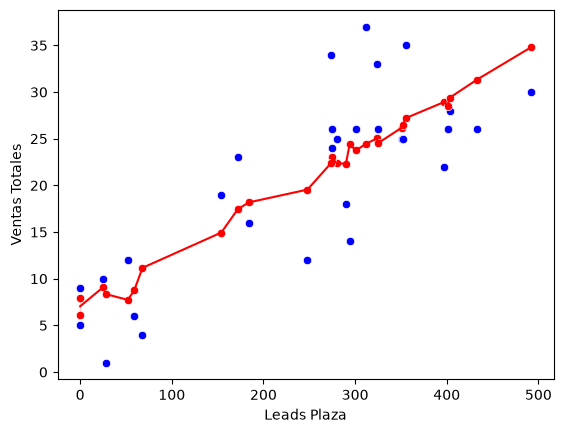

In [28]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='Leads Plaza', y='Ventas Totales', color="blue", data=data1)
sns.scatterplot(x='Leads Plaza', y='Predicciones', color="red", data=data1)
sns.lineplot(x='Leads Plaza', y='Predicciones', color="red", data=data1)

In [29]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.6607995377730069

In [30]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8128957730072207)

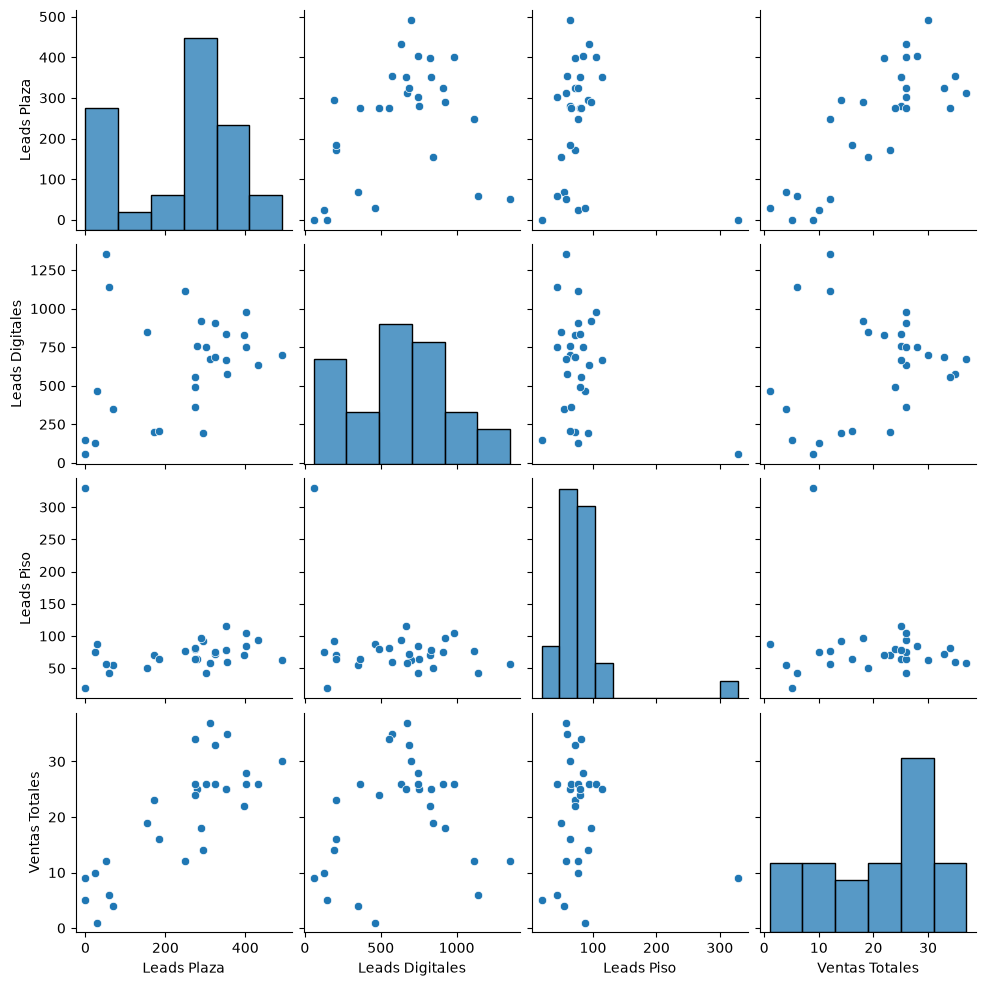

In [34]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(
    data1[
        [
            'Leads Plaza',
            'Leads Digitales',
            'Leads Piso',
            'Ventas Totales'
        ]
    ]
)

In [39]:
variables_regresion = data1[
    [
        'Leads Plaza',
        'Leads Digitales',
        'Leads Piso',
        'Ventas Totales'
    ]
]

In [40]:
# Encontramos las correlaciones únicamente entre variables numéricas

Corr_Factors = variables_regresion.corr(numeric_only=True)

Corr_Factors

Marketing,Leads Plaza,Leads Digitales,Leads Piso,Ventas Totales
Marketing,,,,
Leads Plaza,1.000000,0.317247,-0.133673,0.809212
Leads Digitales,0.317247,1.000000,-0.280795,0.190744
Leads Piso,-0.133673,-0.280795,1.000000,-0.122982
Ventas Totales,0.809212,0.190744,-0.122982,1.000000


In [41]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

Marketing,Leads Plaza,Leads Digitales,Leads Piso,Ventas Totales
Marketing,,,,
Leads Plaza,1.000000,0.317247,0.133673,0.809212
Leads Digitales,0.317247,1.000000,0.280795,0.190744
Leads Piso,0.133673,0.280795,1.000000,0.122982
Ventas Totales,0.809212,0.190744,0.122982,1.000000


<Axes: xlabel='Marketing', ylabel='Marketing'>

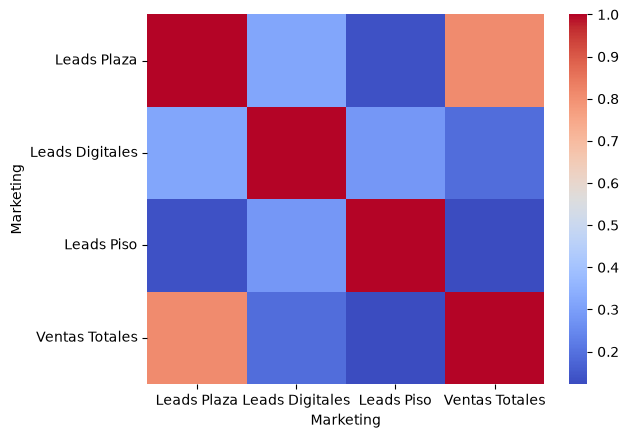

In [42]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')  
Heat_Map

<Axes: xlabel='Marketing', ylabel='Marketing'>

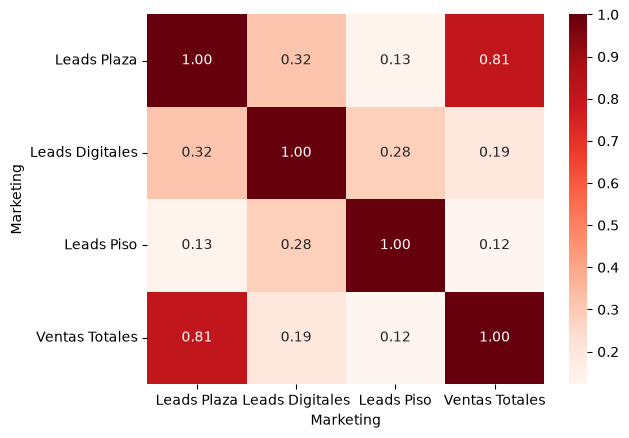

In [44]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Reds', annot=True, fmt=".2f")  
Heat_Map

In [52]:
df = pd.read_csv(
    "Analisis GAC Full7agosto 2026(SDC ).csv"
)

df.head(10)

,Solicitudes de Credito,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ventas,NaN,12,7,8,13,6,21,17,17,...,41,41,35,37,33,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total 2024,Total 2025,Total 2026,NaN,NaN
4,Generadas,5,6,11,23,26,43,55,36,56,...,85,74,95,82,32,519,1178,450,1697.0,39%
5,Aprobadas,1,2,7,14,8,13,30,19,26,...,41,42,44,35,12,215,451,201,666.0,0.509009009
6,Condicionadas,0,0,1,0,4,0,3,0,1,...,14,16,17,10,9,100,287,102,387.0,NaN
7,Rechazadas,4,4,4,9,14,22,17,13,13,...,30,16,30,33,9,163,392,137,555.0,NaN
8,Formalizadas,1,1,5,11,3,6,17,9,7,...,18,16,19,13,4,105,234,91,339.0,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Seleccionamos Mes, Ventas y resultados de solicitudes de crédito

df1 = df.iloc[
    [3, 1, 5, 6, 7],
    2:32
].copy()

df1

,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
3,"Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24","Octubre, 24","Noviembre, 24",...,"Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26"
1,12,7,8,13,6,21,17,17,23,22,...,40,42,34,38,30,41,41,35,37,33
5,2,7,14,8,13,30,19,26,31,25,...,51,49,31,37,37,41,42,44,35,12
6,0,1,0,4,0,3,0,1,32,26,...,22,32,49,34,21,14,16,17,10,9
7,4,4,9,14,22,17,13,13,12,25,...,62,36,28,36,25,30,16,30,33,9


In [54]:
df1.index = [
    'Mes',
    'Ventas',
    'Aprobadas',
    'Condicionadas',
    'Rechazadas'
]

In [55]:
df1= df1.T
df1 = df1.reset_index(drop=True)

df1

,Mes,Ventas,Aprobadas,Condicionadas,Rechazadas
0,"Febrero, 24",12,2,0,4
1,"Marzo, 24",7,7,1,4
2,"Abril, 24",8,14,0,9
3,"Mayo, 24",13,8,4,14
4,"Junio, 24",6,13,0,22
5,"Julio, 24",21,30,3,17
6,"Agosto, 24",17,19,0,13
7,"Septiembre, 24",17,26,1,13
8,"Octubre, 24",23,31,32,12
9,"Noviembre, 24",22,25,26,25


In [56]:
columnas_numericas = [
    'Ventas',
    'Aprobadas',
    'Condicionadas',
    'Rechazadas'
]

df1[columnas_numericas] = df1[
    columnas_numericas
].apply(pd.to_numeric, errors='coerce')

In [57]:
df1.info()
df1.isnull().sum()
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Mes            30 non-null     str  
 1   Ventas         30 non-null     int64
 2   Aprobadas      30 non-null     int64
 3   Condicionadas  30 non-null     int64
 4   Rechazadas     30 non-null     int64
dtypes: int64(4), str(1)
memory usage: 1.3 KB


,Mes,Ventas,Aprobadas,Condicionadas,Rechazadas
0,"Febrero, 24",12,2,0,4
1,"Marzo, 24",7,7,1,4
2,"Abril, 24",8,14,0,9
3,"Mayo, 24",13,8,4,14
4,"Junio, 24",6,13,0,22


<Axes: xlabel='Aprobadas', ylabel='Ventas'>

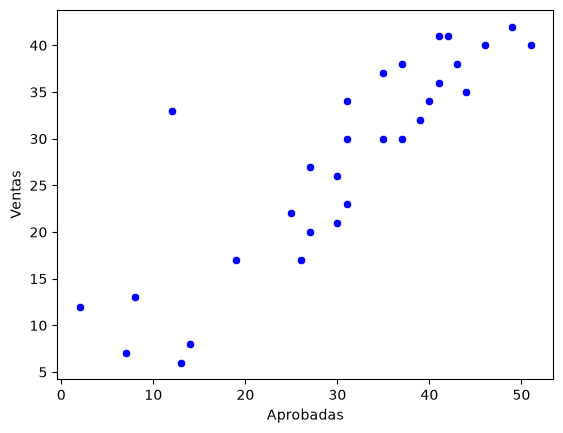

In [58]:
# Imprimimos el scatter plot entre la variable dependiente (Ventas)
# y la variable independiente (Aprobadas)

from turtle import color

sns.scatterplot(
    x='Aprobadas',
    y='Ventas',
    color='blue',
    data=df1
)

In [59]:
# Declaramos las variables dependiente e independientes
# para la regresión lineal múltiple

# Variables independientes
Vars_Indep = df1[
    ['Aprobadas', 'Condicionadas', 'Rechazadas']
]

# Variable dependiente
Var_Dep = df1['Ventas']

In [60]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [61]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.65,0.14,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Aprobadas','Condicionadas','Rechazadas']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.427
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [62]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Aprobadas', 'Condicionadas', 'Rechazadas'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.64812279, 0.13669227, 0.00824749]),
 'rank_': np.int64(3),
 'singular_': array([105.52202754,  48.52272261,  38.65937265]),
 'intercept_': np.float64(5.426785113125636)}

In [63]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7700386635237688

In [64]:
#Predecimos los valores de total de accidentes a partir de la variable "alcohol"
#y_pred= model.predict(X=df[['alcohol', 'speeding']])
y_pred= model.predict(X=df1[['Aprobadas', 'Condicionadas', 'Rechazadas']])
y_pred

array([ 6.75602064, 10.13332687, 14.57473157, 11.27400132, 14.03382609,
       25.42075294, 17.84833547, 22.52188729, 29.99171413, 25.39004107,
       35.42885353, 28.50221024, 25.55975855, 29.45670752, 29.06319622,
       32.51472982, 38.83918498, 35.27921654, 26.29621979, 38.07434459,
       41.99962154, 41.85586404, 32.44744249, 34.35177507, 32.48405322,
       34.16093593, 34.96697847, 36.51538111, 29.75017255, 14.50871642])

In [65]:
#Insertamos la columna de predicciones en el DataFrame
df1.insert(0, 'Predicciones', y_pred)
df1

,Predicciones,Mes,Ventas,Aprobadas,Condicionadas,Rechazadas
0,6.756021,"Febrero, 24",12,2,0,4
1,10.133327,"Marzo, 24",7,7,1,4
2,14.574732,"Abril, 24",8,14,0,9
3,11.274001,"Mayo, 24",13,8,4,14
4,14.033826,"Junio, 24",6,13,0,22
5,25.420753,"Julio, 24",21,30,3,17
6,17.848335,"Agosto, 24",17,19,0,13
7,22.521887,"Septiembre, 24",17,26,1,13
8,29.991714,"Octubre, 24",23,31,32,12
9,25.390041,"Noviembre, 24",22,25,26,25


<Axes: xlabel='Aprobadas', ylabel='Ventas'>

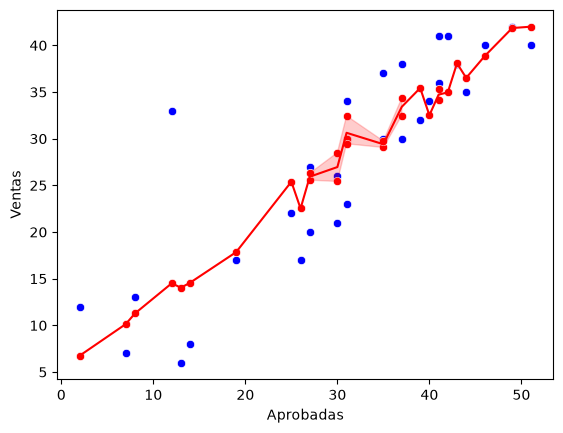

In [66]:
# Visualizamos la gráfica comparativa entre las ventas reales
# y las ventas predichas

sns.scatterplot(
    x='Aprobadas',
    y='Ventas',
    color='blue',
    data=df1
)

sns.scatterplot(
    x='Aprobadas',
    y='Predicciones',
    color='red',
    data=df1
)

sns.lineplot(
    x='Aprobadas',
    y='Predicciones',
    color='red',
    data=df1
)

In [67]:
# Corroboramos cuál es el coeficiente de determinación de nuestro modelo

coef_Deter = model.score(
    X=Vars_Indep,
    y=Var_Dep
)

coef_Deter

0.7700386635237688

In [68]:
# Calculamos la raíz del coeficiente de determinación

coef_Correl = np.sqrt(coef_Deter)

coef_Correl

np.float64(0.8775184690499505)

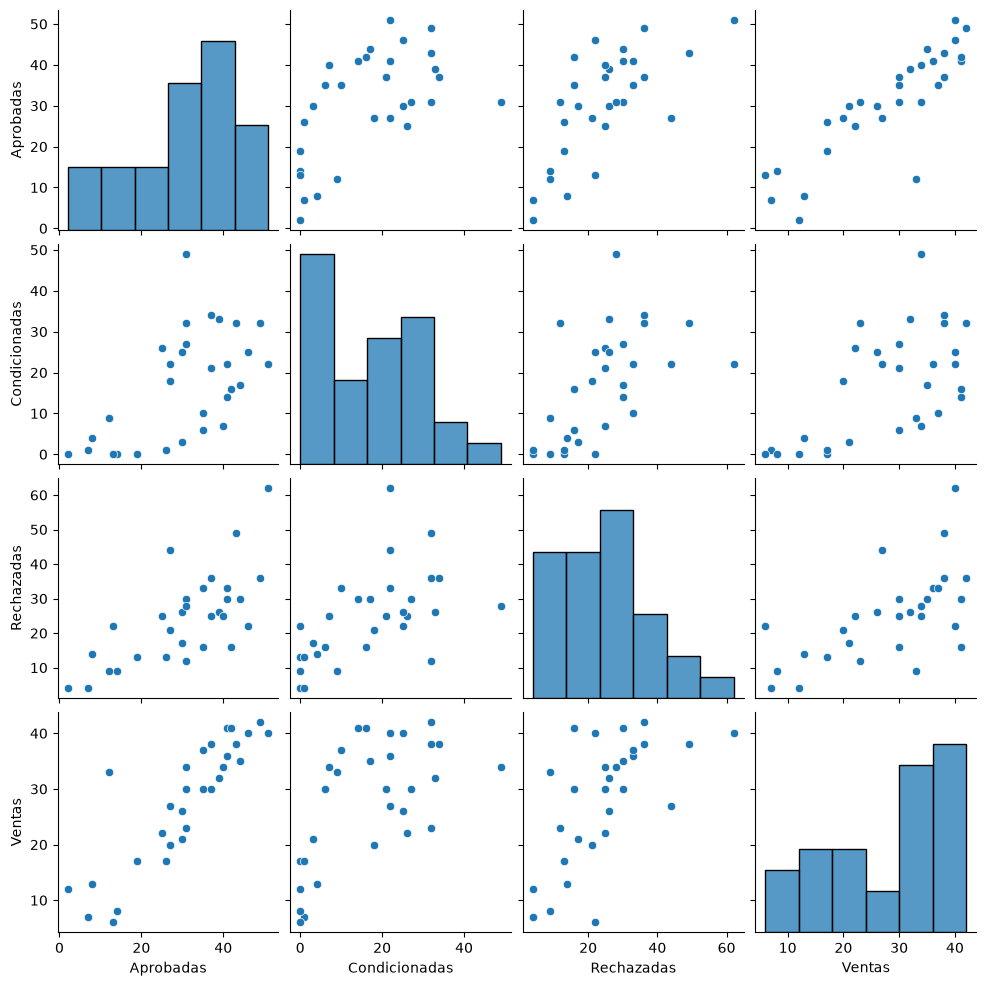

In [69]:
# Graficamos las dispersiones entre las variables del modelo

sns.pairplot(
    df1[
        [
            'Aprobadas',
            'Condicionadas',
            'Rechazadas',
            'Ventas'
        ]
    ]
)

In [70]:
# Seleccionamos únicamente las variables de la regresión

variables_regresion = df1[
    [
        'Aprobadas',
        'Condicionadas',
        'Rechazadas',
        'Ventas'
    ]
]

In [71]:
# Encontramos las correlaciones únicamente entre variables numéricas

Corr_Factors = variables_regresion.corr(numeric_only=True)

Corr_Factors

,Aprobadas,Condicionadas,Rechazadas,Ventas
Aprobadas,1.000000,0.580790,0.699188,0.867210
Condicionadas,0.580790,1.000000,0.561796,0.612701
Rechazadas,0.699188,0.561796,1.000000,0.636590
Ventas,0.867210,0.612701,0.636590,1.000000


In [72]:
# Encontramos el valor absoluto de todas las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Aprobadas,Condicionadas,Rechazadas,Ventas
Aprobadas,1.000000,0.580790,0.699188,0.867210
Condicionadas,0.580790,1.000000,0.561796,0.612701
Rechazadas,0.699188,0.561796,1.000000,0.636590
Ventas,0.867210,0.612701,0.636590,1.000000


<Axes: >

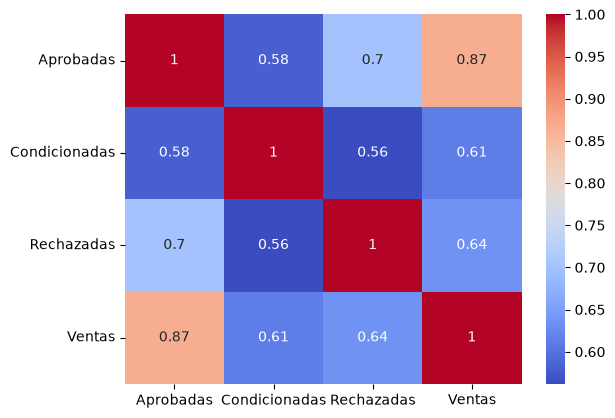

In [73]:
# Graficamos el mapa de calor de los coeficientes de correlación

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap='coolwarm',
    annot=True
)

Heat_Map

<Axes: >

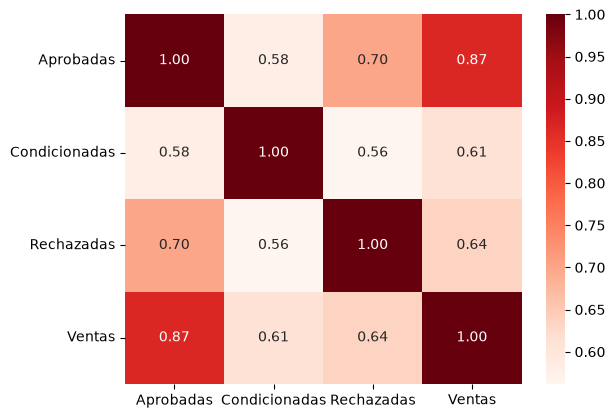

In [74]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Reds', annot=True, fmt=".2f")  
Heat_Map